## Business Objective

The goal of this analysis is to evaluate business performance across multiple dimensions such as revenue, profitability, regional performance, and cost structure.

We aim to identify key drivers of profit, detect inefficiencies, and uncover actionable insights that can help improve overall business performance.

## Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)

# Load dataset
df = pd.read_csv("../data/raw/financial_data.csv")

# Convert date
df["date"] = pd.to_datetime(df["date"])

df.head()

,company,date,revenue,expense,cogs,gross_profit,operating_profit,net_profit,category,region
0,AlphaCorp,2023-01-01,1204.74,1070.83,642.76,561.98,306.65,207.13,Operations,North
1,AlphaCorp,2023-01-02,1136.69,552.70,293.98,842.71,641.94,399.49,HR,West
2,AlphaCorp,2023-01-03,932.83,536.13,269.80,663.03,518.99,459.15,HR,East
3,AlphaCorp,2023-01-04,1181.94,1160.88,625.94,555.99,133.55,78.39,Marketing,South
4,AlphaCorp,2023-01-05,1285.87,877.94,520.44,765.44,529.20,465.74,Operations,East


## Dataset Overview

In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nDate Range:", df["date"].min(), "to", df["date"].max())
print("\nCompanies:", df["company"].nunique())
print("\nCategories:", df["category"].unique())
print("\nRegions:", df["region"].unique())

Shape: (2190, 10)

Columns:
 Index(['company', 'date', 'revenue', 'expense', 'cogs', 'gross_profit',
       'operating_profit', 'net_profit', 'category', 'region'],
      dtype='object')

Date Range: 2023-01-01 00:00:00 to 2024-12-30 00:00:00

Companies: 3

Categories: ['Operations' 'HR' 'Marketing' 'IT']

Regions: ['North' 'West' 'East' 'South']


## Time Series Analysis (Revenue & Analysis)

## Revenue Trend Analysis

We begin by analyzing the overall revenue trend over time.

The data shows a consistent upward trend in revenue, indicating strong business growth and increasing market demand. However, periodic fluctuations suggest the presence of seasonal patterns.

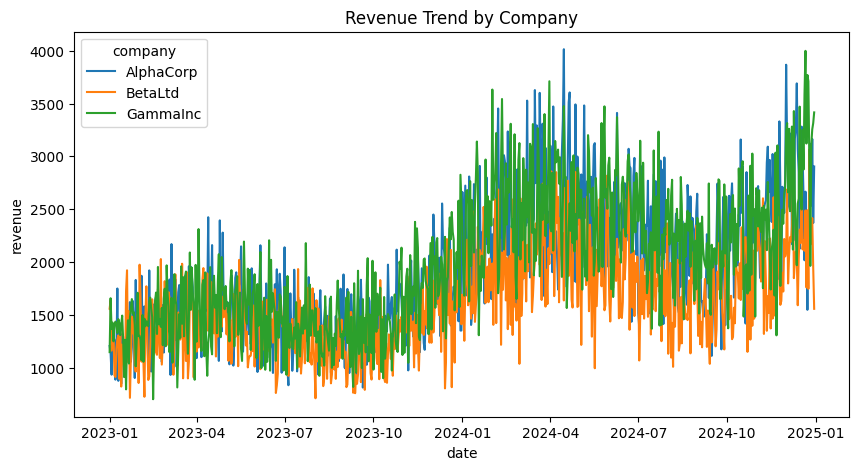

In [3]:
sns.lineplot(data=df, x="date", y="revenue", hue="company")
plt.title("Revenue Trend by Company")
plt.show()

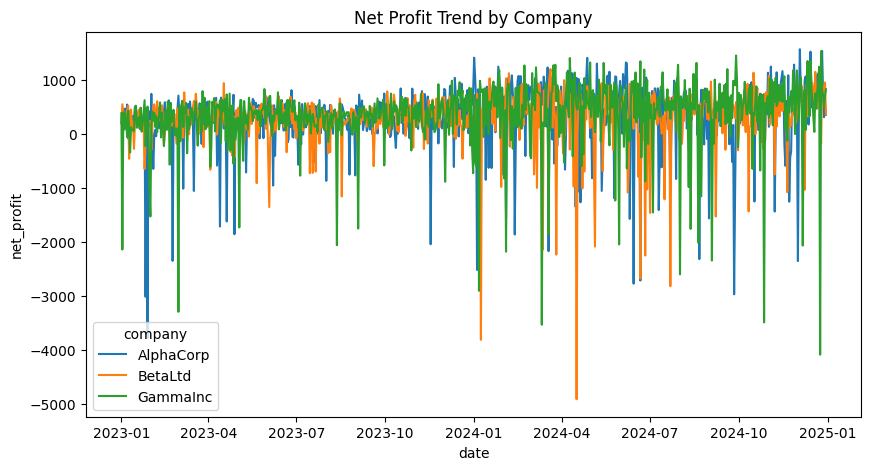

In [4]:
sns.lineplot(data=df, x="date", y="net_profit", hue="company")
plt.title("Net Profit Trend by Company")
plt.show()

### Key Insight:
While revenue growth is a positive indicator, it is important to assess whether this growth is translating into proportional profit gains.

## Profitability Analysis
Next, we analyze profitability across different companies.

In [7]:
df["profit_margin"] = df["net_profit"] / df["revenue"]

# Average margin per company
margin_by_company = df.groupby("company")["profit_margin"].mean()
print(margin_by_company)

company
AlphaCorp    0.185941
BetaLtd      0.198928
GammaInc     0.199563
Name: profit_margin, dtype: float64


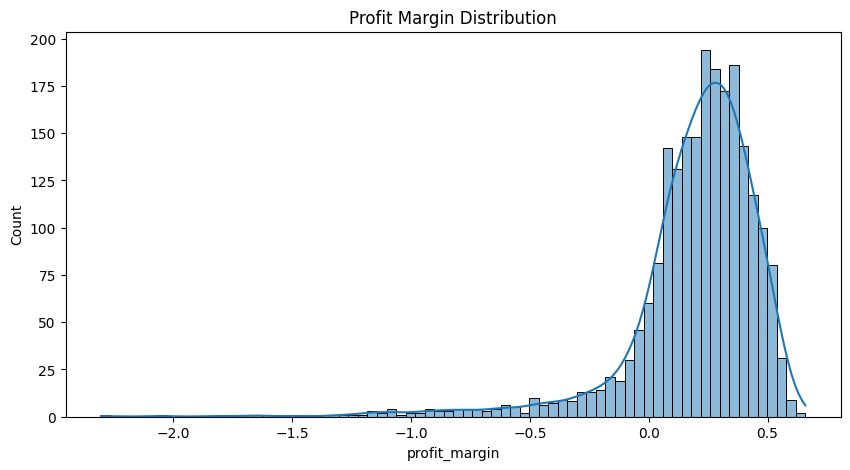

In [8]:
# Distribution
sns.histplot(df["profit_margin"], kde=True)
plt.title("Profit Margin Distribution")
plt.show()

It is observed that some companies achieve higher profit margins than others, despite similar revenue levels. This indicates differences in cost efficiency and operational performance.

### Key Insight:
Higher revenue does not necessarily guarantee higher profitability. Efficient cost management plays a crucial role in determining overall financial success.

## Regional Performance Analysis

We examine performance across different regions to understand geographical variations.

In [9]:
region_summary = df.groupby("region").agg({
    "revenue": "sum",
    "net_profit": "mean",
    "expense": "mean"
})

print(region_summary)

           revenue  net_profit      expense
region                                     
East     952625.65  339.393950  1402.447576
North   1051592.01  300.310108  1646.923591
South    872692.78  456.659346  1247.149673
West    1156008.86  198.978112  1955.790270


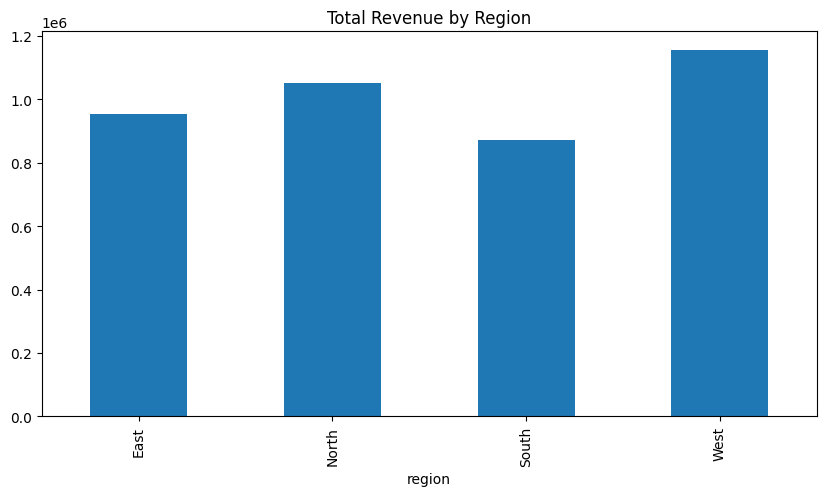

In [10]:
region_summary["revenue"].plot(kind="bar")
plt.title("Total Revenue by Region")
plt.show()

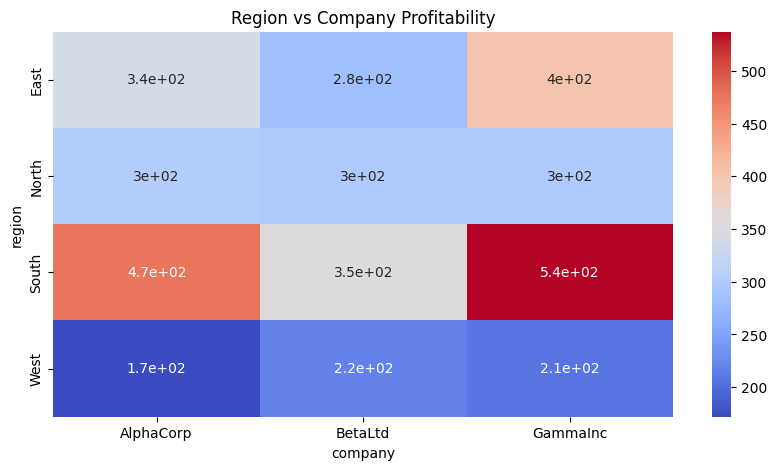

In [19]:
pivot = df.pivot_table(
    values="net_profit",
    index="region",
    columns="company",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Region vs Company Profitability")
plt.show()

Certain regions generate high revenue but show relatively low profitability, suggesting higher operational costs. On the other hand, some regions achieve better profit margins despite lower revenue.

### Key Insight:
Regional inefficiencies exist, where high revenue regions are not necessarily the most profitable. This highlights the need for region-specific cost optimization strategies.

## Category-wise Cost Analysis

Analyzing the distribution of expenses across categories reveals that certain cost components, particularly marketing and operations, contribute significantly to total expenses.

In [11]:
df["expense_ratio"] = df["expense"] / df["revenue"]

category_summary = df.groupby("category").agg({
    "expense": "mean",
    "expense_ratio": "mean"
})

print(category_summary)

                expense  expense_ratio
category                              
HR           941.298656       0.641296
IT          1466.611264       0.737816
Marketing   2379.438688       1.094538
Operations  1528.304844       0.833586


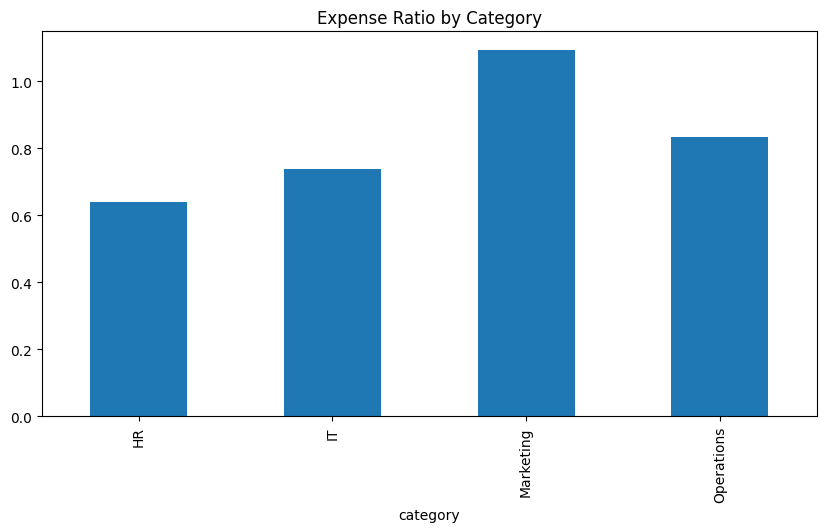

In [12]:
category_summary["expense_ratio"].plot(kind="bar")
plt.title("Expense Ratio by Category")
plt.show()

In some cases, expense ratios exceed expected levels, indicating potential overspending or inefficiencies.

### Key Insight:
Excessive spending in key areas, especially marketing, may not be yielding proportional returns, pointing to a need for better budget allocation and ROI analysis.

## Risk & Loss Analysis

In [13]:
# High expense ratio
high_risk = df[df["expense_ratio"] > 1.5]
print("High risk records:", len(high_risk))
high_risk.head()

High risk records: 82


,company,date,revenue,expense,cogs,gross_profit,operating_profit,net_profit,category,region,profit_margin,expense_ratio
25,AlphaCorp,2023-01-26,1308.33,5220.24,2751.18,-1442.85,-2954.23,-3015.77,Marketing,East,-2.305053,3.990003
27,AlphaCorp,2023-01-28,1829.72,5917.00,3158.40,-1328.68,-3688.08,-3770.99,Marketing,West,-2.060966,3.233828
33,AlphaCorp,2023-02-03,1869.11,3202.66,1972.19,-103.07,-782.48,-648.80,Marketing,West,-0.347117,1.713468
53,AlphaCorp,2023-02-23,1589.70,4250.14,2159.64,-569.94,-2263.91,-2350.51,Marketing,North,-1.478587,2.673548
75,AlphaCorp,2023-03-17,1581.08,2768.73,1567.80,13.28,-947.28,-1057.21,Marketing,South,-0.668663,1.751164


In [14]:
# Negative profit cases
loss_cases = df[df["net_profit"] < 0]
print("Loss cases:", len(loss_cases))
loss_cases.head()

Loss cases: 295


,company,date,revenue,expense,cogs,gross_profit,operating_profit,net_profit,category,region,profit_margin,expense_ratio
7,AlphaCorp,2023-01-08,1122.23,1046.99,703.60,418.63,4.16,-86.48,Operations,East,-0.077061,0.932955
25,AlphaCorp,2023-01-26,1308.33,5220.24,2751.18,-1442.85,-2954.23,-3015.77,Marketing,East,-2.305053,3.990003
27,AlphaCorp,2023-01-28,1829.72,5917.00,3158.40,-1328.68,-3688.08,-3770.99,Marketing,West,-2.060966,3.233828
32,AlphaCorp,2023-02-02,1360.19,1207.61,764.77,595.43,127.14,-18.69,Operations,South,-0.013741,0.887824
33,AlphaCorp,2023-02-03,1869.11,3202.66,1972.19,-103.07,-782.48,-648.80,Marketing,West,-0.347117,1.713468


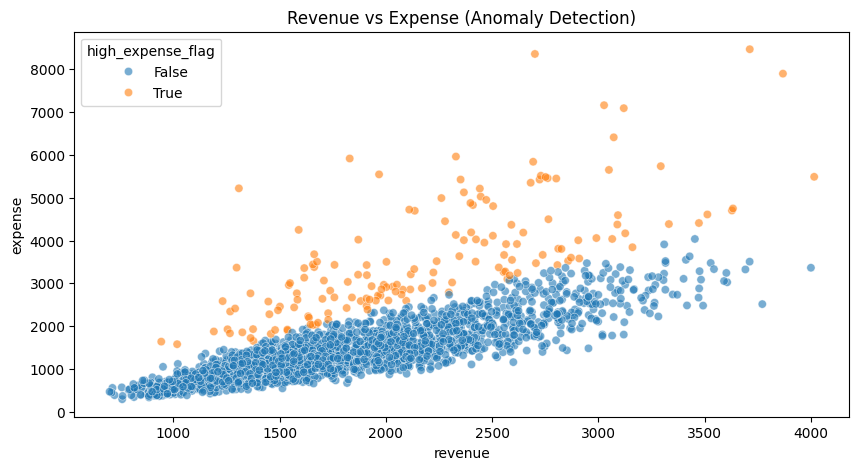

In [18]:
df["expense_ratio"] = df["expense"] / df["revenue"]
df["high_expense_flag"] = df["expense_ratio"] > 1.2
sns.scatterplot(
    data=df,
    x="revenue",
    y="expense",
    hue="high_expense_flag",  # if from transform.py
    alpha=0.6
)

plt.title("Revenue vs Expense (Anomaly Detection)")
plt.show()


We identify transactions where expenses exceed revenue, resulting in losses.

A notable number of such cases exist, along with high-risk instances characterized by unusually high expense levels.

### Key Insight:
Frequent loss-making transactions and high-risk cases indicate gaps in cost control mechanisms and highlight the need for better monitoring and anomaly detection.

## Company Comparision

In [14]:
company_summary = df.groupby("company").agg({
    "revenue": "sum",
    "net_profit": "sum",
    "profit_margin": "mean"
})

print(company_summary)

              revenue  net_profit  profit_margin
company                                         
AlphaCorp  1406529.65   234648.67       0.185941
BetaLtd    1182395.57   210548.84       0.198928
GammaInc   1443994.08   259212.34       0.199563


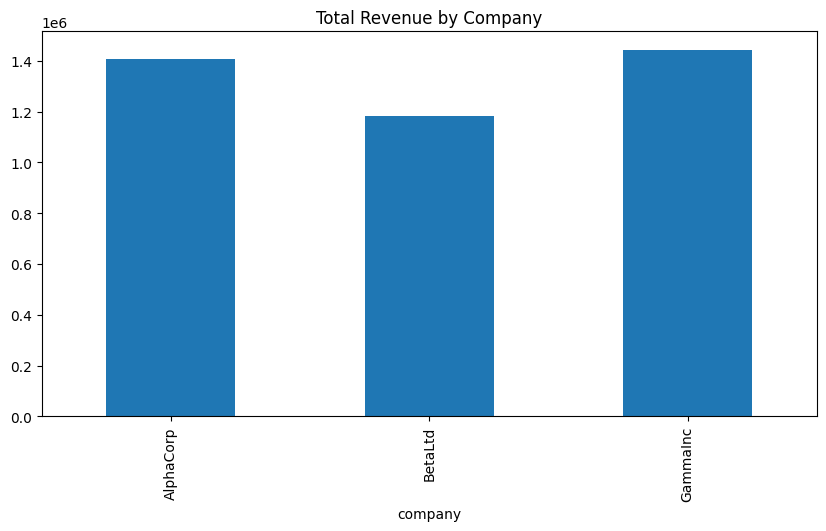

In [15]:
company_summary["revenue"].plot(kind="bar")
plt.title("Total Revenue by Company")
plt.show()

In [20]:
company_rank = df.groupby("company")["net_profit"].sum().sort_values(ascending=False)
print(company_rank)

company
GammaInc     259212.34
AlphaCorp    234648.67
BetaLtd      210548.84
Name: net_profit, dtype: float64


## Correlation Analysis

Correlation analysis reveals strong relationships between financial variables.

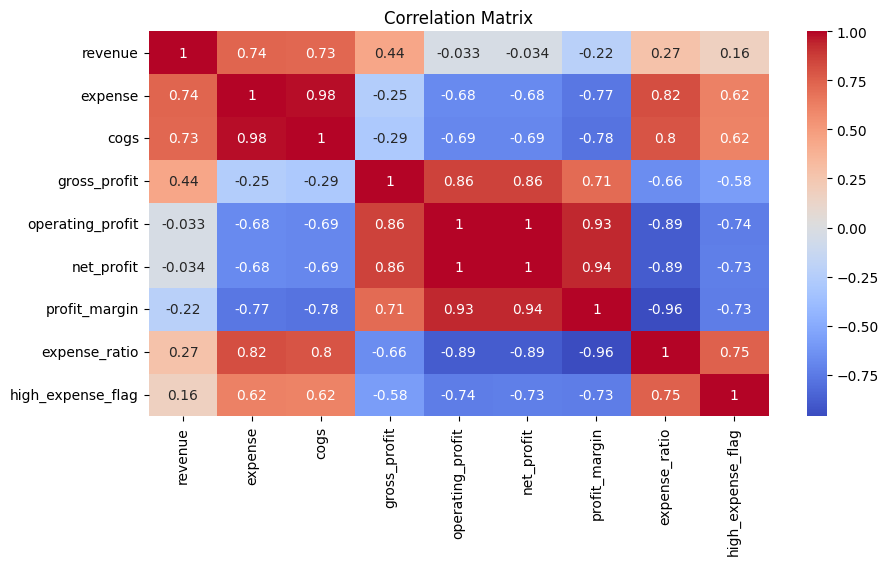

In [25]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [26]:
print(corr["net_profit"].sort_values(ascending=False))

net_profit           1.000000
operating_profit     0.996046
profit_margin        0.938575
gross_profit         0.857248
revenue             -0.034393
expense             -0.677984
cogs                -0.691428
high_expense_flag   -0.731495
expense_ratio       -0.889446
Name: net_profit, dtype: float64


Net profit shows a strong negative correlation with expense ratio, indicating that higher expenses directly reduce profitability. In contrast, revenue has a weaker direct impact on net profit.

### Key Insight:
Profitability is more sensitive to cost control than revenue growth, making expense management a critical factor for business success.

## Trend Smoothing Using Moving Average

To better understand long-term trends, moving averages are used to smooth short-term fluctuations.

This provides a clearer view of the underlying growth pattern and helps identify deviations from expected performance.

In [17]:
df = df.sort_values(["company", "date"])

df["revenue_ma"] = df.groupby("company")["revenue"].transform(
    lambda x: x.rolling(30).mean()
)

df["growth_rate"] = df.groupby("company")["revenue"].pct_change()

df[["date", "revenue", "revenue_ma"]].head()

,date,revenue,revenue_ma
0,2023-01-01,1204.74,NaN
730,2023-01-01,1557.72,NaN
1460,2023-01-01,1146.51,NaN
1,2023-01-02,1136.69,NaN
731,2023-01-02,1636.06,NaN


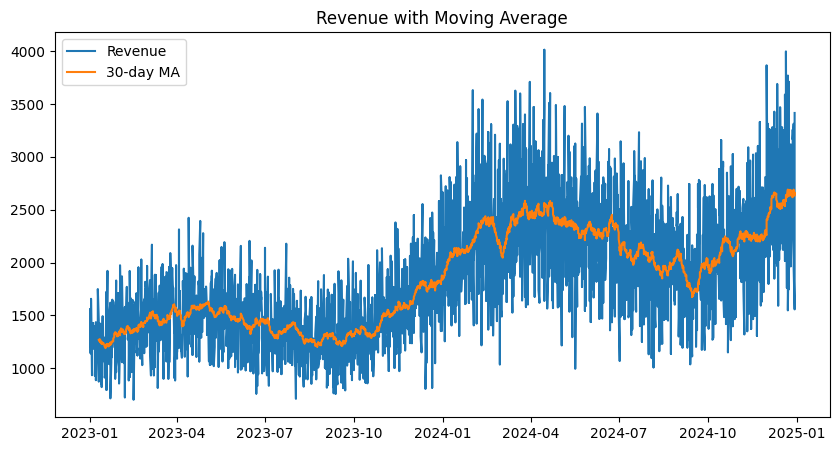

In [18]:
plt.plot(df["date"], df["revenue"], label="Revenue")
plt.plot(df["date"], df["revenue_ma"], label="30-day MA")
plt.legend()
plt.title("Revenue with Moving Average")
plt.show()

### Key Insight:
Smoothed trends enable better forecasting and early detection of unusual variations in business performance.

## Final Insights and Recommendations

Based on the analysis, the following key conclusions can be drawn:

- The business is experiencing steady revenue growth.
- However, profitability is constrained by high operational and marketing expenses.
- Certain regions generate high revenue but suffer from low efficiency.
- Cost control has a significantly greater impact on profit than revenue growth.
- Efficient regions demonstrate that better cost management can improve profitability.

### Recommendations:

- Optimize costs in high-revenue but low-profit regions.
- Re-evaluate marketing strategies to improve return on investment.
- Implement monitoring systems to detect and control high-risk transactions.
- Replicate best practices from high-performing regions across the business.